# 0400 anemia model: baseline prevalence vs the GBD anemia envelope

Population-level calibration check for the non-simulation anemia model: the baseline-scenario
anemia prevalence in `0400_non_pregnant_anemia_model/results` (quintiles collapsed with the
stratified population) against GBD's all-anemia envelope (rei 192, como, GBD 2023 release 16,
year 2023). Version-free filename by convention: rerun per model iteration and commit.

Reading notes:
- The model covers the **non-pregnant** population while the GBD envelope is the total
  population, so a small gap is expected at reproductive ages (pregnancy raises anemia
  prevalence and pregnant women are ~2-6% of WRA).
- The model derives anemia by integrating threshold densities over its hemoglobin
  distribution (custom MEs 10487/10488, 250-draw subset); GBD's envelope comes from the same
  hemoglobin modeling, so agreement should be close but not exact.
- Baseline includes baseline-fortification mixing where configured (a no-op for Ethiopia).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from loguru import logger

logger.disable("vivarium_gbd_access")  # its cache-config DEBUG lines carry timestamps that would pollute rerun diffs

from db_queries import get_age_metadata
from get_draws.api import get_draws
from vivarium_inputs import utility_data

REPO = Path.cwd().parents[2]
arms = sorted(
    (p.parts[-2], p.parts[-1])
    for p in (REPO / "0400_non_pregnant_anemia_model/results").glob("*/*")
    if (p / "anemia_prevalence.parquet").exists()
)
arms

[('bouillon', 'nigeria'),
 ('rice', 'india'),
 ('rice', 'nigeria'),
 ('salt', 'ethiopia')]

In [2]:
ages = get_age_metadata(release_id=16)[["age_group_id", "age_group_years_start", "age_group_years_end"]]
ages.columns = ["age_group_id", "age_start", "age_end"]

gbd = {}
for location in sorted({loc for _, loc in arms}):
    draws = get_draws(
        gbd_id_type="rei_id",
        gbd_id=192,  # all-anemia envelope (205/206/207 are the severities)
        location_id=utility_data.resolve_location(location.title()),
        sex_id=[1, 2],
        year_id=2023,
        release_id=16,
        source="como",
        measure_id=5,  # prevalence
        metric_id=3,  # rate
        age_group_id=ages.age_group_id.tolist(),
    )
    draws = draws[draws.cause_id == 294]
    draw_cols = [c for c in draws.columns if c.startswith("draw_")]
    g = draws.merge(ages, on="age_group_id")
    g["sex"] = g.sex_id.map({1: "Male", 2: "Female"})
    gbd[location] = g.set_index(["sex", g.age_start.round(4), g.age_end.round(4)])[draw_cols] \
        .mean(axis=1).rename("gbd")
    print(f"{location}: {len(gbd[location])} sex-age rows")

/mnt/team/simulation_science/priv/engineering/jenkins/shared_envs/vivarium_gates_lsff_2026_artifact_current/lib/python3.11/site-packages/get_draws/api.py:194: UserWarning: No version_id was specified, so get_draws will automatically determine a best version ID to use from the given parameters. If you want to retrieve a specific version please pass a version_id directly.
  warnings.warn(


ethiopia: 50 sex-age rows


/mnt/team/simulation_science/priv/engineering/jenkins/shared_envs/vivarium_gates_lsff_2026_artifact_current/lib/python3.11/site-packages/get_draws/api.py:194: UserWarning: No version_id was specified, so get_draws will automatically determine a best version ID to use from the given parameters. If you want to retrieve a specific version please pass a version_id directly.
  warnings.warn(


india: 50 sex-age rows


/mnt/team/simulation_science/priv/engineering/jenkins/shared_envs/vivarium_gates_lsff_2026_artifact_current/lib/python3.11/site-packages/get_draws/api.py:194: UserWarning: No version_id was specified, so get_draws will automatically determine a best version ID to use from the given parameters. If you want to retrieve a specific version please pass a version_id directly.
  warnings.warn(


nigeria: 50 sex-age rows


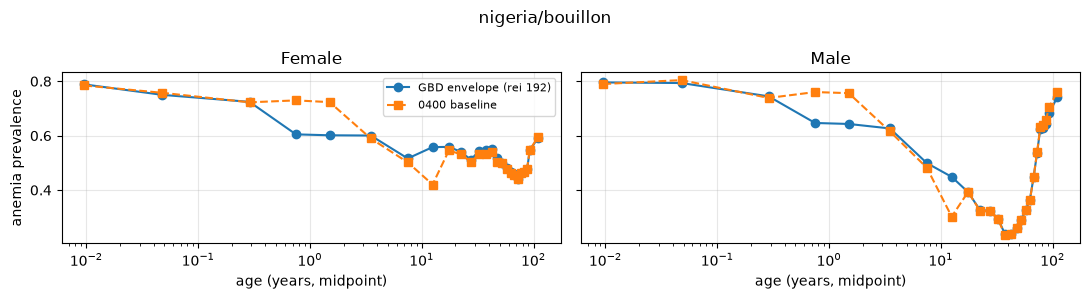

nigeria/bouillon largest deviations:
                           model     gbd   ratio
sex    age_start age_end                        
Male   10.0      15.0     0.3022  0.4485  0.6738
Female 10.0      15.0     0.4203  0.5579  0.7534
       0.5       1.0      0.7296  0.6047  1.2066
       1.0       2.0      0.7232  0.6013  1.2027



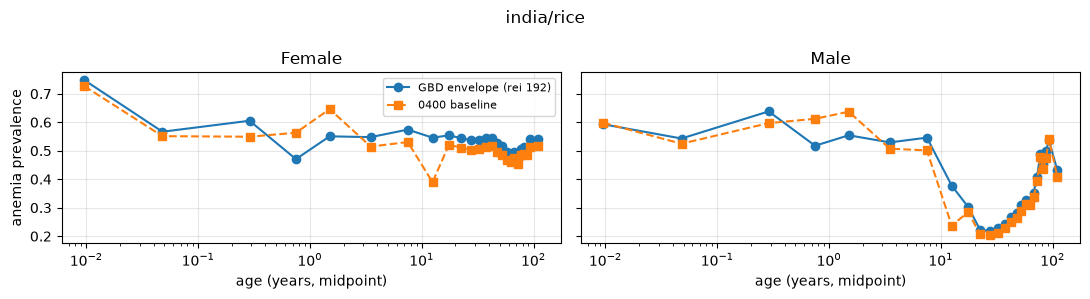

india/rice largest deviations:
                           model     gbd   ratio
sex    age_start age_end                        
Male   10.0      15.0     0.2373  0.3777  0.6282
Female 10.0      15.0     0.3894  0.5458  0.7135
       0.5       1.0      0.5631  0.4705  1.1968
Male   0.5       1.0      0.6121  0.5175  1.1827



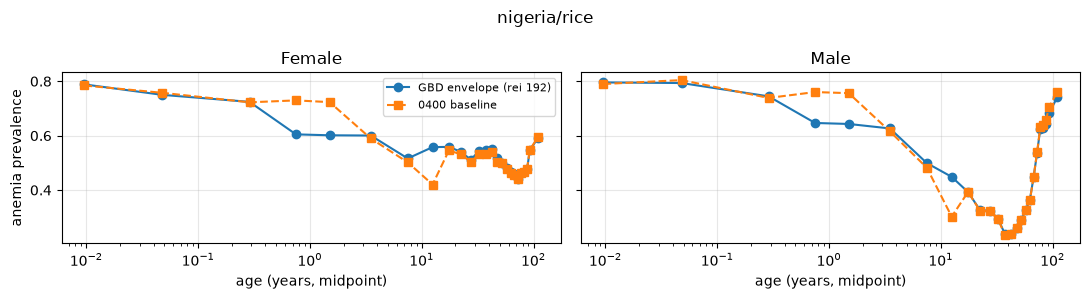

nigeria/rice largest deviations:
                           model     gbd   ratio
sex    age_start age_end                        
Male   10.0      15.0     0.3022  0.4485  0.6738
Female 10.0      15.0     0.4203  0.5579  0.7534
       0.5       1.0      0.7296  0.6047  1.2066
       1.0       2.0      0.7232  0.6013  1.2027



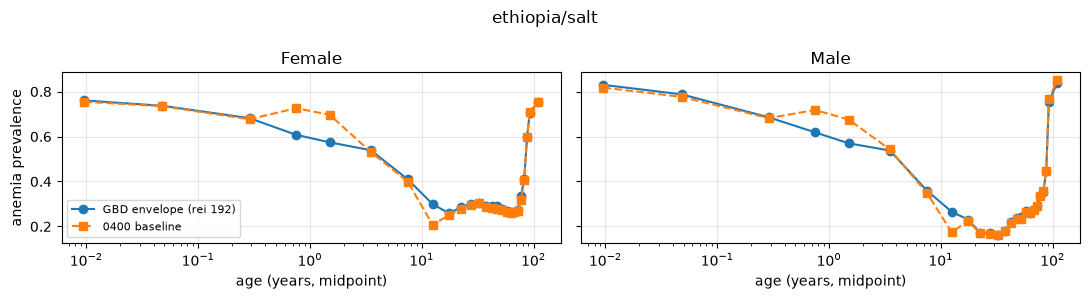

ethiopia/salt largest deviations:
                           model     gbd   ratio
sex    age_start age_end                        
Male   10.0      15.0     0.1739  0.2652  0.6558
Female 10.0      15.0     0.2074  0.2992  0.6930
       1.0       2.0      0.6969  0.5742  1.2138
       0.5       1.0      0.7259  0.6078  1.1943

             arm median ratio max |ratio-1| WRA median ratio
nigeria/bouillon        0.996         32.6%            0.977
      india/rice        0.948         37.2%            0.941
    nigeria/rice        0.996         32.6%            0.977
   ethiopia/salt        0.988         34.4%            0.980


In [3]:
def model_prevalence(vehicle, location):
    """Baseline anemia prevalence by sex and age, quintiles collapsed with the
    non-pregnant stratified population."""
    prev = pd.read_parquet(
        REPO / f"0400_non_pregnant_anemia_model/results/{vehicle}/{location}/anemia_prevalence.parquet"
    )
    prev = prev[prev.scenario == "baseline"].drop(columns="scenario")
    pop = pd.read_csv(REPO / f"0100_data_prep/results/population/stratified/{location}.csv")
    pop = pop[pop.pregnant == "not_pregnant"].drop(columns="pregnant")
    key = ["sex", "age_start", "age_end", "wealth_quintile"]
    m = prev.merge(pop, on=key, suffixes=("", "_pop"))
    assert len(m) == len(prev), "population rows missing for some strata"
    m["cases"] = m.value * m.value_pop
    out = m.groupby(["sex", m.age_start.round(4), m.age_end.round(4)]).apply(
        lambda g: g.cases.sum() / g.value_pop.sum()
    ).rename("model")
    return out


summaries = []
for vehicle, location in arms:
    cmp = pd.concat([model_prevalence(vehicle, location), gbd[location]], axis=1).dropna()
    cmp["ratio"] = cmp.model / cmp.gbd
    mid = (cmp.index.get_level_values(1) + cmp.index.get_level_values(2)) / 2
    fig, axes = plt.subplots(1, 2, figsize=(11, 3), sharey=True)
    for ax, sex in zip(axes, ["Female", "Male"]):
        s = cmp.xs(sex, level="sex")
        x = (s.index.get_level_values(0) + s.index.get_level_values(1)) / 2
        ax.plot(x, s.gbd, "o-", label="GBD envelope (rei 192)")
        ax.plot(x, s.model, "s--", label="0400 baseline")
        ax.set_xscale("log")
        ax.grid(alpha=0.3)
        ax.set_title(sex)
        ax.set_xlabel("age (years, midpoint)")
    axes[0].set_ylabel("anemia prevalence")
    axes[0].legend(fontsize=8)
    fig.suptitle(f"{location}/{vehicle}")
    fig.tight_layout()
    plt.show()
    wra = cmp.xs("Female", level="sex").loc[
        (cmp.xs("Female", level="sex").index.get_level_values(0) >= 15)
        & (cmp.xs("Female", level="sex").index.get_level_values(1) <= 50)
    ]
    summaries.append((f"{location}/{vehicle}", f"{cmp.ratio.median():.3f}",
                      f"{(cmp.ratio - 1).abs().max():.1%}", f"{wra.ratio.median():.3f}"))
    worst = cmp.reindex((cmp.ratio - 1).abs().sort_values(ascending=False).index).head(4)
    print(f"{location}/{vehicle} largest deviations:")
    print(worst.round(4).to_string())
    print()

print(pd.DataFrame(summaries, columns=["arm", "median ratio", "max |ratio-1|", "WRA median ratio"])
      .to_string(index=False))

Interpretation: ratios near 1 mean the model's hemoglobin-threshold anemia reproduces GBD's
envelope. A modest deficit at reproductive ages is the expected non-pregnant restriction.

**The two systematic deviations are threshold-vintage differences, pinned 2026-09-02.**
The model's threshold file (`/share/mnch/anemia/code/reference/model/anemia_thresholds.csv`,
dated March 2022 -- GBD 2021 era) uses 110 g/L for all under-5s and 115 for all of ages 5-14.
The GBD 2023 como envelope follows the WHO 2024 revised cutoffs: **105 g/L at 6-23 months and
120 g/L at 12-14 years**. Re-running the model's own machinery (custom-ME hemoglobin + the
lsff ensemble CDF) with those cutoffs reproduces the envelope to within the same ~3-7%
residual seen at every other age. Probe values (Nigeria): F 10-14 with cutoff 115 gives 0.402
vs envelope 0.558, with 120 gives 0.521 (envelope x 0.93 -- the neighboring-age residual);
F 6-11 months with 110 gives 0.713 vs envelope 0.605, with 105 gives 0.579 (envelope x 1.04).
Hemoglobin inputs and distribution shape are NOT implicated -- ages 2-4, 5-9, and all adult
groups agree to within 3-7% under the file's cutoffs.

Fix: refresh the threshold table (including the mild/moderate/severe sub-cutoffs, which the
WHO 2024 revision also moved) to the GBD 2023 scheme -- get the canonical file from the
anemia team rather than hand-editing rows.